In [1]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
np.random.seed(0)
x = np.linspace(500, 2500, 20)  # square footage
true_w = 200  # dollars per sqft
noise = np.random.normal(0, 20000, size=x.shape)
y = true_w * x + noise

In [3]:
# Prior on w ~ N(μ0, τ²)
mu0 = 100
tau2 = 100**2

# Known noise variance
sigma2 = 20000**2

In [4]:
# Posterior mean and variance of w (univariate case)
xn = x
yn = y
post_var = 1 / (1 / tau2 + (np.sum(xn**2) / sigma2))
post_mean = post_var * (mu0 / tau2 + np.sum(xn * yn) / sigma2)

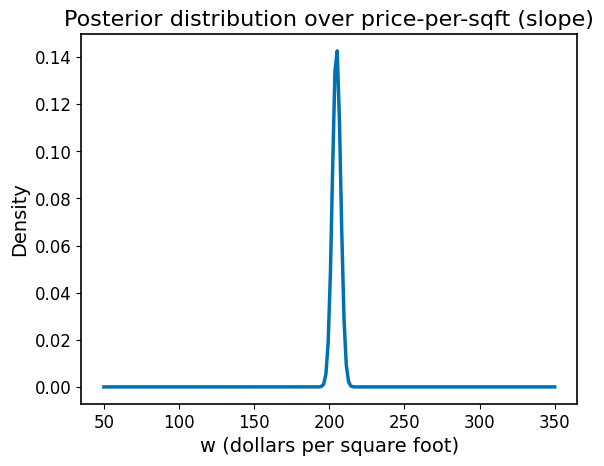

In [5]:
# Plot
w_vals = np.linspace(50, 350, 200)
post_pdf = norm.pdf(w_vals, post_mean, np.sqrt(post_var))

plt.plot(w_vals, post_pdf)
plt.title("Posterior distribution over price-per-sqft (slope)")
plt.xlabel("w (dollars per square foot)")
plt.ylabel("Density")
plt.show()

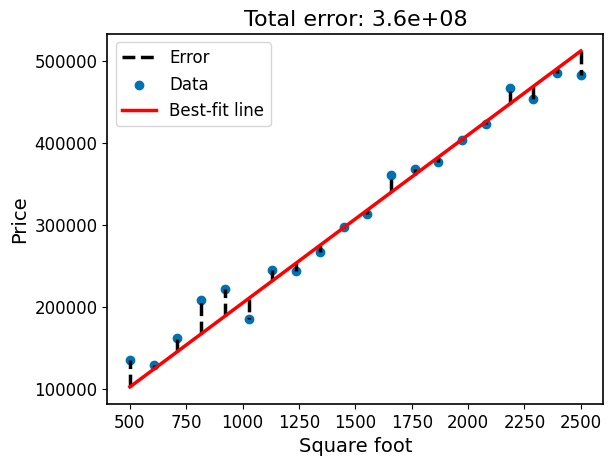

In [19]:
xs = np.linspace(500, 2500, 101)
ys = xs * post_mean

error = 0
for i, (x_i, y_i) in enumerate(zip(x, y)):
    pred_y_i = x_i * post_mean
    plt.vlines(
        x_i, 
        pred_y_i, 
        y_i, 
        linestyle="--", 
        color="k", 
        label="Error" if i == 0 else None,
    )
    error += (pred_y_i - y_i) ** 2
error /= len(x)

plt.scatter(x, y, label="Data")
plt.plot(xs, ys, c="r", label="Best-fit line")

plt.xlabel("Square foot")
plt.ylabel("Price")
plt.title(f"Total error: {error / 10**8:.1f}" + "e+08")
plt.legend()

plt.show()

In [27]:
post_mean

np.float64(204.8428317690332)

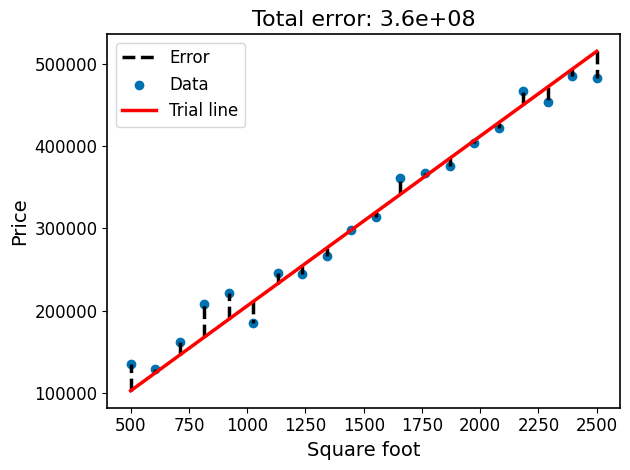

In [37]:
slope = 206

xs = np.linspace(500, 2500, 101)
ys = xs * slope

error = 0
for i, (x_i, y_i) in enumerate(zip(x, y)):
    pred_y_i = x_i * slope
    plt.vlines(
        x_i, 
        pred_y_i, 
        y_i, 
        linestyle="--", 
        color="k", 
        label="Error" if i == 0 else None,
    )
    error += (pred_y_i - y_i) ** 2
error /= len(x)

plt.scatter(x, y, label="Data")
plt.plot(xs, ys, c="r", label="Trial line")

plt.xlabel("Square foot")
plt.ylabel("Price")
plt.title(f"Total error: {error / 10**8:.1f}" + "e+08")
plt.legend()

plt.tight_layout()
plt.show()